Analises exploratoria da query 1: Questoes a responder

Objetivo: analisar salários e distribuição geográfica (Cidade, Estado ou País). 

In [2]:
# 1. Importamos as bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [3]:
# 2. Carregar os dados da Query 1
df_query1 = pd.read_csv('CSV_da_query_1.csv')
print('base de dados carregada!')

base de dados carregada!


In [4]:
# 3. Visualização Inicial dos Dados
print("Query 1 - primeiras linhas:")
df_query1.head()

Query 1 - primeiras linhas:


,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,SALARY,DEPARTMENT_NAME,DEPARTMENT_ID,JOB_TITLE,JOB_ID
0,100,Steven,King,24000,Executive,90.0,President,AD_PRES
1,101,Neena,Yang,17000,Executive,90.0,Administration Vice President,AD_VP
2,102,Lex,Garcia,17000,Executive,90.0,Administration Vice President,AD_VP
3,145,John,Singh,14000,Sales,80.0,Sales Manager,SA_MAN
4,146,Karen,Partners,13500,Sales,80.0,Sales Manager,SA_MAN


In [5]:
# 3.1 Visualização Inicial dos Dados - Informações gerais
print("Informações gerais do DataFrame:")
df_query1.info()

Informações gerais do DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   EMPLOYEE_ID      107 non-null    int64  
 1   FIRST_NAME       107 non-null    str    
 2   LAST_NAME        107 non-null    str    
 3   SALARY           107 non-null    int64  
 4   DEPARTMENT_NAME  106 non-null    str    
 5   DEPARTMENT_ID    106 non-null    float64
 6   JOB_TITLE        107 non-null    str    
 7   JOB_ID           107 non-null    str    
dtypes: float64(1), int64(2), str(5)
memory usage: 6.8 KB


In [6]:
# 4. Estatísticas Descritivas de Salário 
df_query1['SALARY'].describe().round(2)

count      107.00
mean      6461.83
std       3909.58
min       2100.00
25%       3100.00
50%       6200.00
75%       8900.00
max      24000.00
Name: SALARY, dtype: float64

In [7]:
# 5. Estatísticas Descritivas por Departamento
print("Distribuição de Funcionários por Departamento:")
df_query1['DEPARTMENT_NAME'].value_counts()

Distribuição de Funcionários por Departamento:


DEPARTMENT_NAME
Shipping            45
Sales               34
Finance              6
Purchasing           6
IT                   5
Executive            3
Marketing            2
Accounting           2
Public Relations     1
Human Resources      1
Administration       1
Name: count, dtype: int64

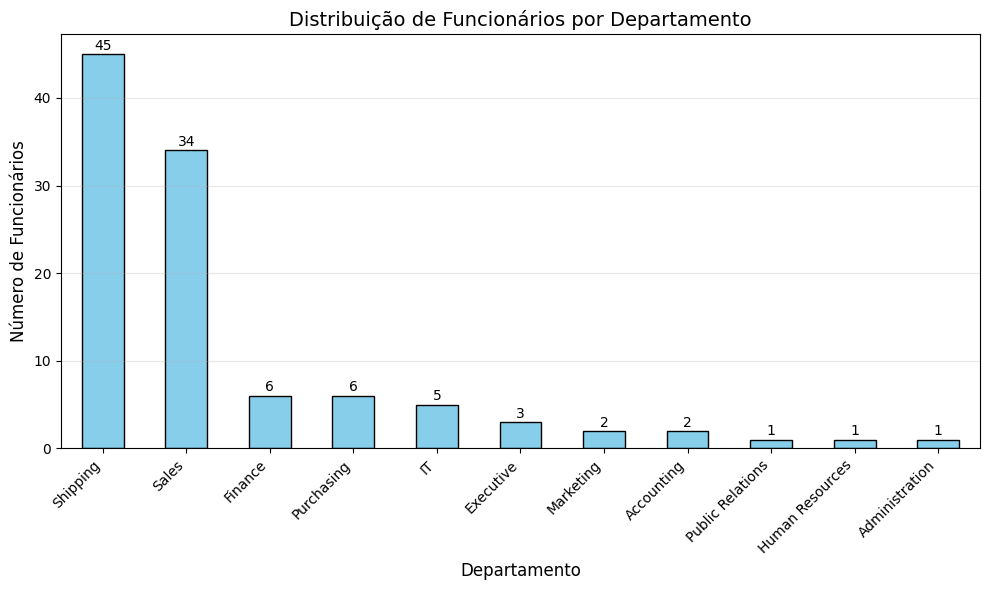

In [8]:
# 5.1 Gráfico de Barras Complementario- Funcionários por Departamento

# Contagem de funcionários por departamento
contagem_depto = df_query1['DEPARTMENT_NAME'].value_counts()

# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
contagem_depto.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribuição de Funcionários por Departamento', fontsize=14)
plt.xlabel('Departamento', fontsize=12)
plt.ylabel('Número de Funcionários', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Adicionar os valores em cima das barras
for i, v in enumerate(contagem_depto):
    plt.text(i, v + 0.5, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [9]:
# 6. Estatísticas Descritivas de Salário por Departamento
estatisticas_depto = df_query1.groupby('DEPARTMENT_NAME')['SALARY'].agg(
    media='mean',
    mediana='median',
    minimo='min',
    maximo='max',
    desvio_padrao='std',
    contagem='count'
).round(2)

# Ordenar por média salarial (do maior para o menor)
estatisticas_depto = estatisticas_depto.sort_values('media', ascending=False)

print("="*60)
print("ESTATÍSTICAS DESCRITIVAS - SALÁRIO POR DEPARTAMENTO")
print("="*60)
print(estatisticas_depto)

ESTATÍSTICAS DESCRITIVAS - SALÁRIO POR DEPARTAMENTO
                     media  mediana  minimo  maximo  desvio_padrao  contagem
DEPARTMENT_NAME                                                             
Executive         19333.33  17000.0   17000   24000        4041.45         3
Accounting        10154.00  10154.0    8300   12008        2621.95         2
Public Relations  10000.00  10000.0   10000   10000            NaN         1
Marketing          9500.00   9500.0    6000   13000        4949.75         2
Sales              8955.88   8900.0    6100   14000        2033.68        34
Finance            8601.33   8000.0    6900   12008        1804.13         6
Human Resources    6500.00   6500.0    6500    6500            NaN         1
IT                 5760.00   4800.0    4200    9000        1925.62         5
Administration     4400.00   4400.0    4400    4400            NaN         1
Purchasing         4150.00   2850.0    2500   11000        3362.59         6
Shipping           3475.

C:\Users\miran\AppData\Local\Temp\ipykernel_11300\3319030491.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DEPARTMENT_NAME', y='SALARY', data=df_query1, palette='Set2')


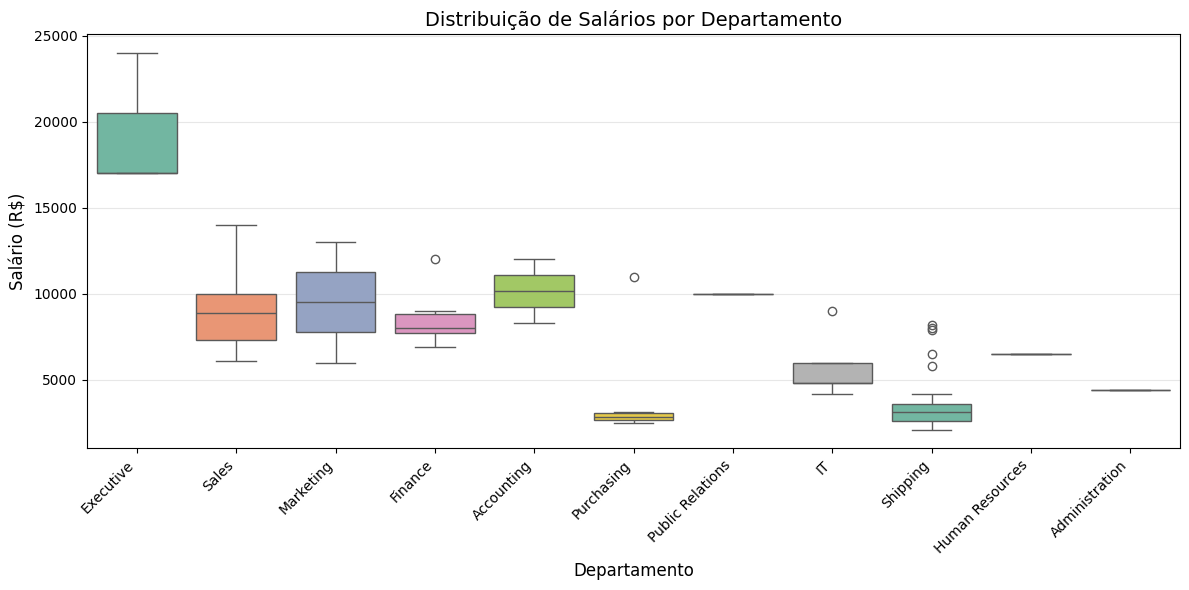

In [10]:
# 6.1 Boxplot - Distribuição de Salários por Departamento

plt.figure(figsize=(12, 6))
sns.boxplot(x='DEPARTMENT_NAME', y='SALARY', data=df_query1, palette='Set2')
plt.title('Distribuição de Salários por Departamento', fontsize=14)
plt.xlabel('Departamento', fontsize=12)
plt.ylabel('Salário (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

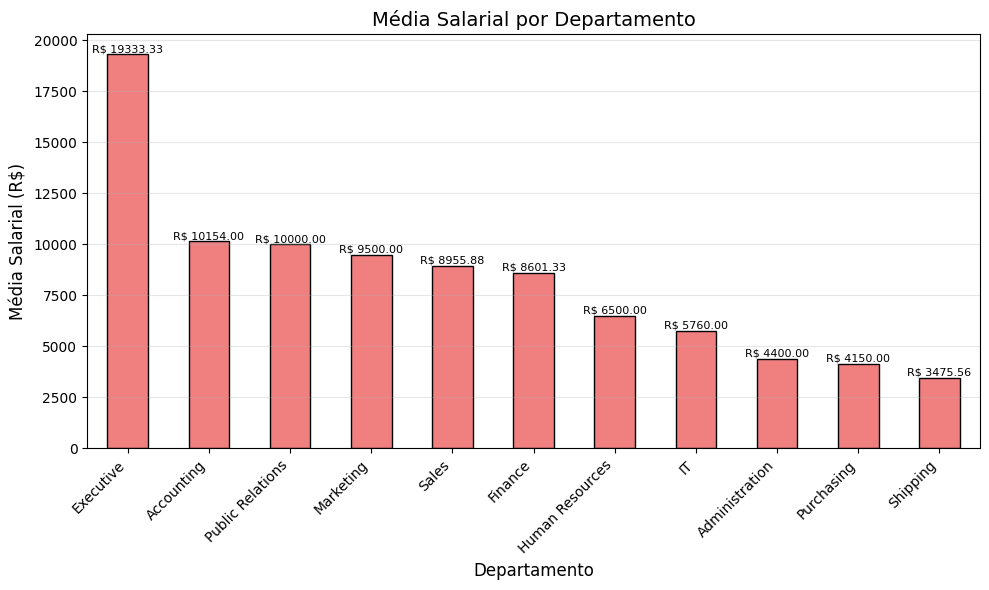

In [11]:
# 6.2 Gráfico de Barras - Média Salarial por Departamento
# 
# Ordenar por média
medias_ordenadas = estatisticas_depto['media'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
medias_ordenadas.plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title('Média Salarial por Departamento', fontsize=14)
plt.xlabel('Departamento', fontsize=12)
plt.ylabel('Média Salarial (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Adicionar valores em cima das barras
for i, v in enumerate(medias_ordenadas):
    plt.text(i, v + 100, f'R$ {v:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [12]:
# 7 Estatísticas descritivas por cargo
estatisticas_cargo = df_query1.groupby('JOB_TITLE')['SALARY'].agg(
    media='mean',
    mediana='median',
    minimo='min',
    maximo='max',
    desvio_padrao='std',
    contagem='count'
).round(2)

# Ordenar por média salarial (do maior para o menor)
estatisticas_cargo = estatisticas_cargo.sort_values('media', ascending=False)

print("="*60)
print("ESTATÍSTICAS DESCRITIVAS - SALÁRIO POR CARGO")
print("="*60)
print(estatisticas_cargo)

ESTATÍSTICAS DESCRITIVAS - SALÁRIO POR CARGO
                                   media  mediana  minimo  maximo  \
JOB_TITLE                                                           
President                        24000.0  24000.0   24000   24000   
Administration Vice President    17000.0  17000.0   17000   17000   
Marketing Manager                13000.0  13000.0   13000   13000   
Sales Manager                    12200.0  12000.0   10500   14000   
Finance Manager                  12008.0  12008.0   12008   12008   
Accounting Manager               12008.0  12008.0   12008   12008   
Purchasing Manager               11000.0  11000.0   11000   11000   
Public Relations Representative  10000.0  10000.0   10000   10000   
Sales Representative              8350.0   8200.0    6100   11500   
Public Accountant                 8300.0   8300.0    8300    8300   
Accountant                        7920.0   7800.0    6900    9000   
Stock Manager                     7280.0   7900.0    5800 

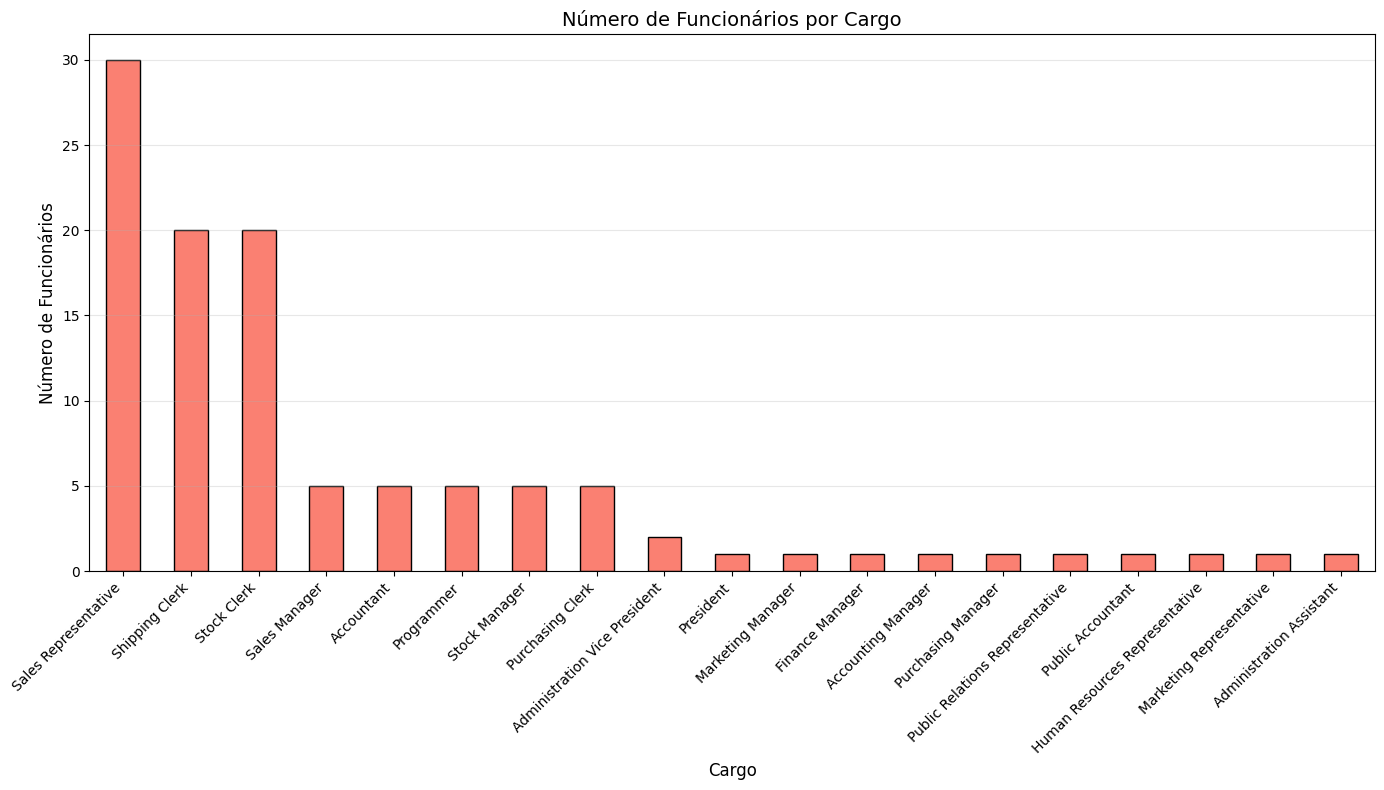

In [13]:
# 7.1 Gráfico de Barras - Funcionários por Cargo

contagem_cargo = df_query1['JOB_TITLE'].value_counts()

plt.figure(figsize=(14, 8))
contagem_cargo.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Número de Funcionários por Cargo', fontsize=14)
plt.xlabel('Cargo', fontsize=12)
plt.ylabel('Número de Funcionários', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\miran\AppData\Local\Temp\ipykernel_11300\874648003.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='JOB_TITLE', y='SALARY', data=df_query1, palette='Set3')


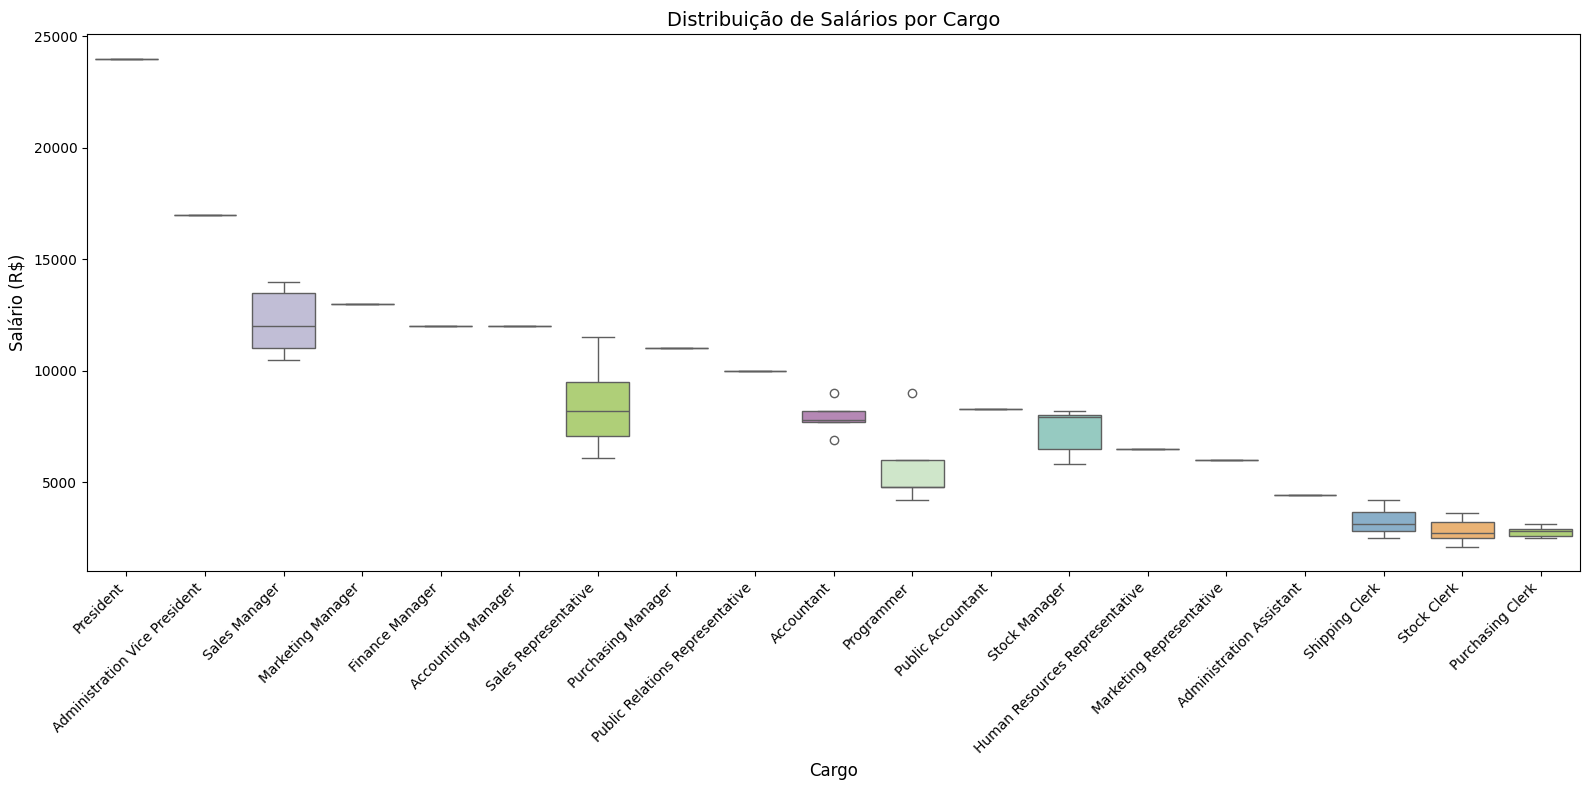

In [14]:
# 7.2 Boxplot - Distribuição salarial por cargo

plt.figure(figsize=(16, 8))
sns.boxplot(x='JOB_TITLE', y='SALARY', data=df_query1, palette='Set3')
plt.title('Distribuição de Salários por Cargo', fontsize=14)
plt.xlabel('Cargo', fontsize=12)
plt.ylabel('Salário (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [15]:
# 8. Conclusões da análise

print("="*60)
print("CONCLUSÕES DA ANÁLISE - QUERY 1")
print("="*60)

print(f"""
📊 PRINCIPAIS INSIGHTS:

1. DEPARTAMENTO COM MAIOR MÉDIA SALARIAL:
   - {estatisticas_depto['media'].idxmax()}: R$ {estatisticas_depto['media'].max():.2f}

2. DEPARTAMENTO COM MENOR MÉDIA SALARIAL:
   - {estatisticas_depto['media'].idxmin()}: R$ {estatisticas_depto['media'].min():.2f}

3. CARGO COM MAIOR MÉDIA SALARIAL:
   - {estatisticas_cargo['media'].idxmax()}: R$ {estatisticas_cargo['media'].max():.2f}

4. CARGO COM MAIS FUNCIONÁRIOS:
   - {estatisticas_cargo['contagem'].idxmax()}: {estatisticas_cargo['contagem'].max()} funcionários

5. TOTAL DE FUNCIONÁRIOS ANALISADOS:
   - {len(df_query1)} funcionários
""")

CONCLUSÕES DA ANÁLISE - QUERY 1

📊 PRINCIPAIS INSIGHTS:

1. DEPARTAMENTO COM MAIOR MÉDIA SALARIAL:
   - Executive: R$ 19333.33

2. DEPARTAMENTO COM MENOR MÉDIA SALARIAL:
   - Shipping: R$ 3475.56

3. CARGO COM MAIOR MÉDIA SALARIAL:
   - President: R$ 24000.00

4. CARGO COM MAIS FUNCIONÁRIOS:
   - Sales Representative: 30 funcionários

5. TOTAL DE FUNCIONÁRIOS ANALISADOS:
   - 107 funcionários

